# Notebook 025 -- Pricing bespoke commodity derivatives, and a lesson

**The question this notebook answers:** if someone handed you a bespoke commodity
derivative tomorrow and asked "what is this worth, and how should our client hedge?",
what would you actually do?

It is a **teaching notebook**, not a "model A beats model B" study, structured in five
parts: **A** the primer (what each instrument *is*), **B** the inputs (where the
numbers come from), **C** the methods (how to actually price each instrument, eight
ways, cross-checked against each other), **D** seven worked hedging case studies, and
**E** honest limits.

### Four things to hold in mind on every page

1. **There are no option prices in this repo. None.** Every premium shown below is a
   *model* price computed from *realised* volatility, never a market quote.
2. **Realised vol is a biased proxy for implied vol.** Options generally trade *above*
   realised volatility (the variance risk premium), so every premium here is probably
   an **underestimate** of what a dealer would actually charge.
3. **No bid-offer, credit, funding, or margin cost is modelled anywhere here.** The gap
   between a model price and a client quote is illustrated once, in Part E, as a
   labelled waterfall -- never elsewhere.
4. **No Sharpe ratio. No returns backtest. No trading rule.** Where a case study shows
   "what would have happened," it is a *realised payoff computation* -- the payoff of a
   defined structure against recorded settlement prices -- never a strategy backtest.

None of the pricing mathematics is new: Black-76 is 1976, Reiner-Rubinstein 1991,
Longstaff-Schwartz 2001. The contribution is the *teaching*: one consistent harness,
real commodity data, cross-validated pricers, and worked client problems.

Full spec: `NEXT_PROMPT.md`. Full narrative and numbers:
`src/results/025_pricing_bespoke_commodity_derivatives.md`.


In [1]:
import json

TMP = "tmp"


def load(name):
    with open(f"{TMP}/{name}") as f:
        return json.load(f)


prereg = load("phase_0_25_preregistration.json")
for line in prereg["honesty_list"]:
    print("-", line)

- No market option prices exist anywhere in this repo. Every premium shown is a model price computed from realised volatility, never a market quote.
- Realised volatility is a downward-biased proxy for implied volatility (the variance risk premium). Options generally trade above realised vol, so every premium in this notebook is probably an underestimate of what a dealer would actually charge.
- No bid-offer, credit, funding, or margin cost is modelled anywhere in this notebook. The gap between a model price and a client quote is illustrated once, in Part E, as a labelled waterfall -- never elsewhere.
- Realised-payoff figures are arithmetic, not backtests: the payoff of a defined structure against recorded settlement prices, over the full sample. There is no trading rule, no Sharpe ratio, and no P&L claim anywhere in this notebook. If a script computes a Sharpe ratio, that is a bug, not a result.


## Phase 0 -- pre-registration

A pedagogical study: no holdout spent, no trading gate. The Phase 2 cross-validation tolerances and the seven case studies' candidate structures were fixed here, before any price was computed.

In [2]:
prereg["case_studies_fixed_in_advance"]

{'A_refiner': {'exposure': 'long crude, short products -- the 3:2:1 crack spread margin, not the oil price',
  'structures': ['sell the crack forward as a swap',
   'buy a crack put (spread option, priced with Kirk and bivariate MC)',
   'a crack collar']},
 'B_wheat_farmer': {'exposure': 'short the harvest price on ZW (cross-check KE); wants a floor, balks at the premium',
  'structures': ['a plain put',
   'a zero-cost collar (solved call strike)',
   'a knock-out put']},
 'C_airline_diesel_buyer': {'exposure': 'buys physical diesel at a monthly average price on HO',
  'structures': ['a strip of futures',
   'an Asian (average-price) call',
   'an Asian collar']},
 'D_gas_utility': {'exposure': 'winter NG demand, seasonal vol (024 Phase 5)',
  'structures': ['a winter strip of futures',
   'a strip of caps (calls)',
   'a cheaper cap with a knock-out on a warm-winter price collapse']},
 'E_producer_negative_prices': {'exposure': 'a $10 put on CL202005 priced as of early April 2020',


## Phase 1 -- market inputs

The forward curve (Nelson-Siegel interpolation, never Gabillon -- 023's gate), and the realised vol term structure, checked against 024's published Samuelson slopes before anything downstream runs.

In [3]:
phase1 = load("phase_1_25_inputs.json")
for p, d in phase1["products"].items():
    fit = d["samuelson_fit_full_sample"]
    print(
        f"{p}: slope={fit['slope']:.3f}  within widened band of 024 = {d['within_widened_band_of_024']}"
    )

CL: slope=-0.153  within widened band of 024 = True
HO: slope=-0.112  within widened band of 024 = True
RB: slope=-0.097  within widened band of 024 = True
NG: slope=-0.282  within widened band of 024 = True
ZW: slope=-0.121  within widened band of 024 = True
KE: slope=-0.115  within widened band of 024 = True
BZ: slope=-0.107  within widened band of 024 = True


In [4]:
import sys

sys.path.insert(0, "tmp")
import matplotlib.pyplot as plt
import viz25 as vz

plt.rcParams["figure.facecolor"] = vz.SURFACE
plt.rcParams["savefig.facecolor"] = vz.SURFACE

# This notebook executes with cwd = src/research/ (its own directory), but
# lib24/lib25's data-directory constants are repo-root-relative strings --
# point them at the repo root explicitly so every chart module's direct
# lib24.load_panel / lib25.fx_series / lib25.discount_curve calls resolve.
import pathlib

import lib24
import lib25

_repo_root = pathlib.Path.cwd().parent.parent
lib24.DATA_DIR = str(_repo_root / "src/research/data/market/databento")
lib25.DATA_DIR = str(_repo_root / "src/research/data/market/databento")
lib25.FRED_DIR = str(_repo_root / "src/research/data/market/fred")
lib25.FX_DIR = str(_repo_root / "src/research/data/market/yfinance/daily")

phase2 = load("phase_2_25_crossval.json")
phase3 = load("phase_3_25_primer.json")
phase4 = load("phase_4_25_methods.json")
phase5 = load("phase_5_25_cases_abcd.json")
phase6 = load("phase_6_25_cases_efg.json")

## Part A -- the primer

What each instrument *is*, taught through pictures: payoff diagrams, real price paths with barriers drawn on them, premium-vs-strike curves.

### A1

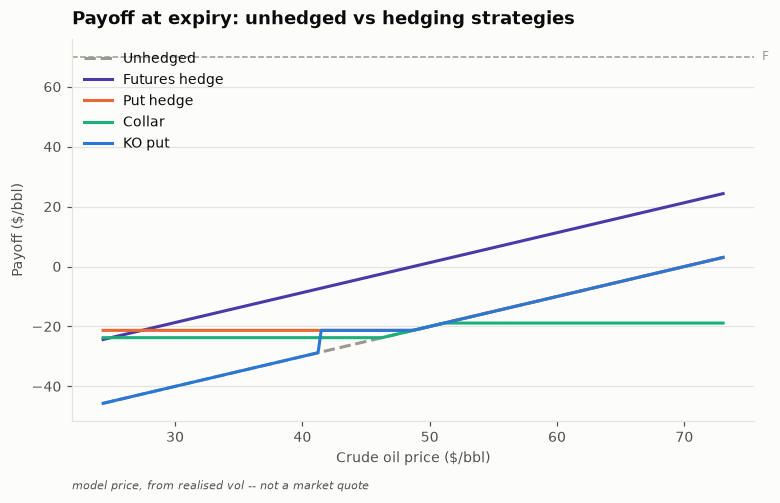

In [5]:
import charts_25_a as ca

fig, ax = ca.fig_a1(phase3)
plt.show()

**What this shows:** Payoff at expiry for an unhedged crude position vs four hedging strategies: futures, vanilla put, collar, and knock-out put.

**Does it match intuition?** KO put is cheaper than vanilla but loses downside protection below the barrier; collar gives a fixed range; futures fully hedges.

### A2

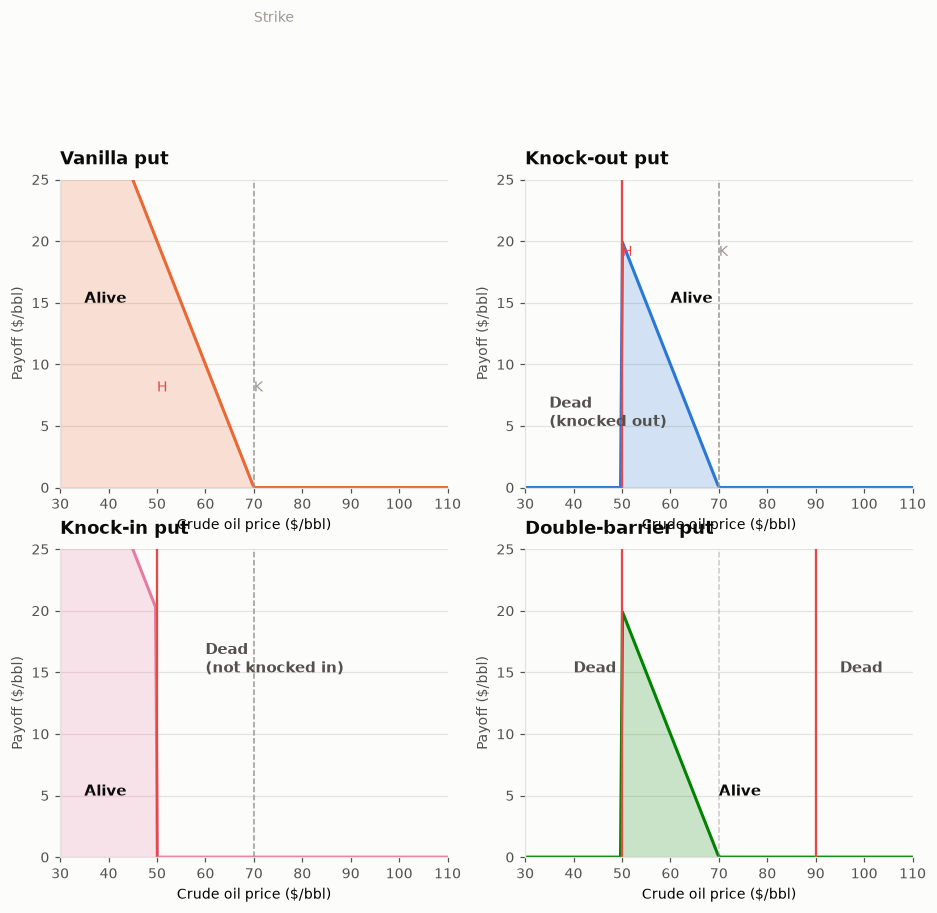

In [6]:
import charts_25_a as ca

fig, ax = ca.fig_a2(phase3)
plt.show()

**What this shows:** Four barrier option types shown in a 2x2 grid: vanilla put, knock-out put, knock-in put, and double-barrier put, with payoff regions shaded and barriers labelled.

**Does it match intuition?** Barriers reduce premium by restricting payoff; knock-out kills the contract if hit, knock-in activates only if hit, double-barrier is alive only between two levels.

### A3

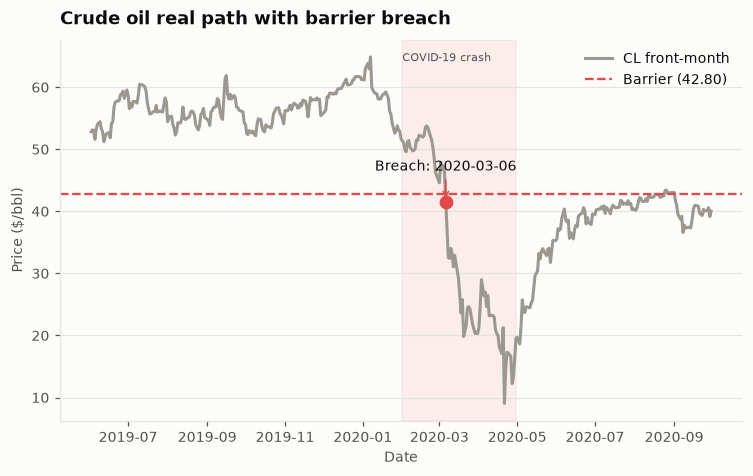

In [7]:
import charts_25_a as ca

fig, ax = ca.fig_a3(phase3)
plt.show()

**What this shows:** Crude oil front-month price path over 16 years with a barrier level marked, showing a real breach during the 2020 crash with date annotated.

**Does it match intuition?** Barriers activate and cancel options in real market conditions; the 2020 oil crash shows how quickly thresholds can be breached.

### A4

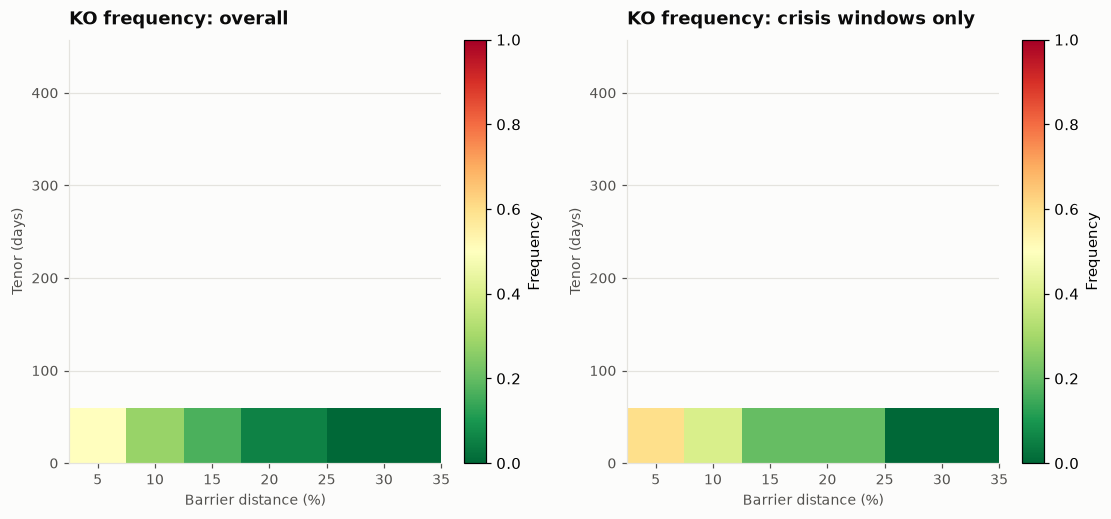

In [8]:
import charts_25_a as ca

fig, ax = ca.fig_a4(phase3)
plt.show()

**What this shows:** Heatmap of knock-out frequency by barrier distance (% of forward) and tenor, split into two panels: overall frequency and crisis-window frequency.

**Does it match intuition?** Lower barriers and longer tenors have higher KO rates; crisis windows show much higher frequencies, justifying the use of wider barriers in volatile regimes.

### A5

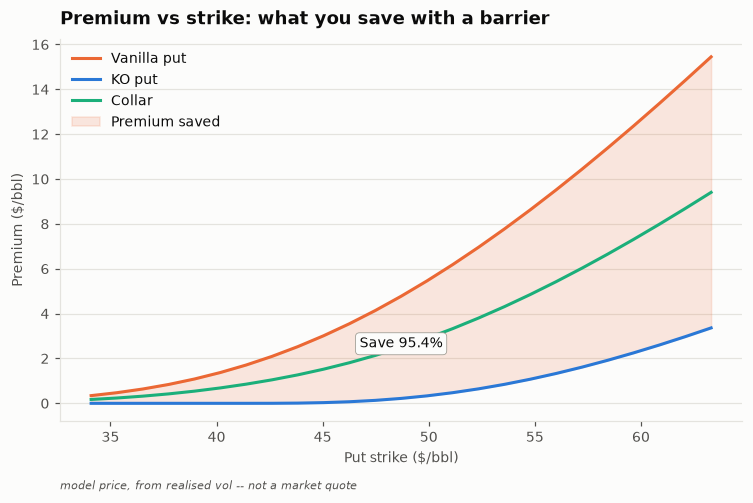

In [9]:
import charts_25_a as ca

fig, ax = ca.fig_a5(phase3)
plt.show()

**What this shows:** Put premium vs strike for vanilla put, collar, and knock-out put, with the savings region (vanilla vs KO) shaded and annotated as a percentage.

**Does it match intuition?** KO puts are cheaper than vanilla because the barrier removes tail risk; the savings increase as you move OTM and use a wider barrier.

### A6

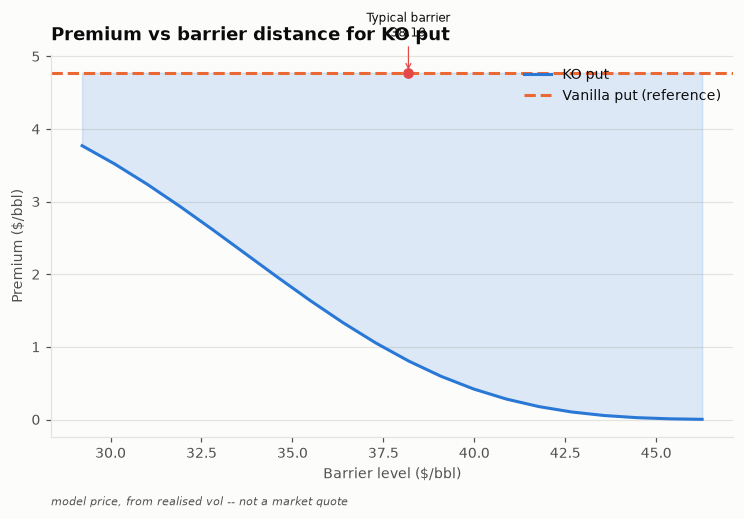

In [10]:
import charts_25_a as ca

fig, ax = ca.fig_a6(phase3)
plt.show()

**What this shows:** Knock-out put premium vs barrier level with a horizontal reference line showing the vanilla put premium.

**Does it match intuition?** As the barrier moves lower (wider), the KO premium falls; the savings vs vanilla increase non-linearly the wider the barrier.

### A7

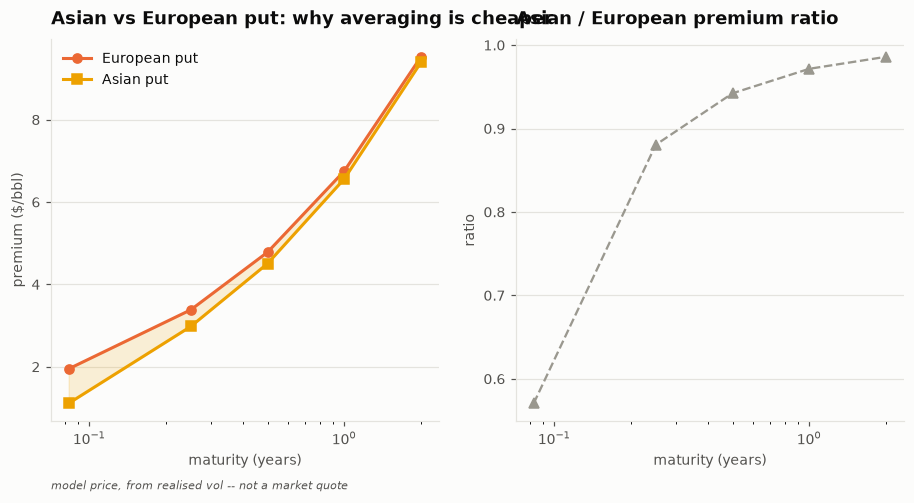

In [11]:
import charts_25_a as ca

fig, ax = ca.fig_a7(phase3)
plt.show()

**What this shows:** Asian put premium vs maturity alongside European put premium, with realised vol of the average overlaid on a twin axis.

**Does it match intuition?** Asian puts are cheaper than European because averaging reduces observed volatility; the divergence widens with tenor.

### A8

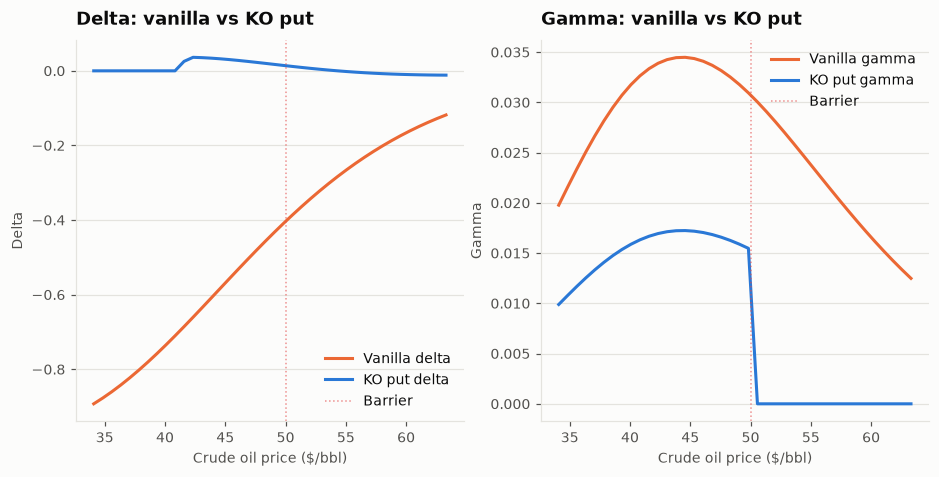

In [12]:
import charts_25_a as ca

fig, ax = ca.fig_a8(phase3)
plt.show()

**What this shows:** Delta and gamma for vanilla vs knock-out put as a function of underlying price, showing the delta discontinuity at the barrier.

**Does it match intuition?** The barrier introduces a delta jump and concentrates gamma; above the barrier, the KO put has zero delta and gamma (it is dead).

### A9

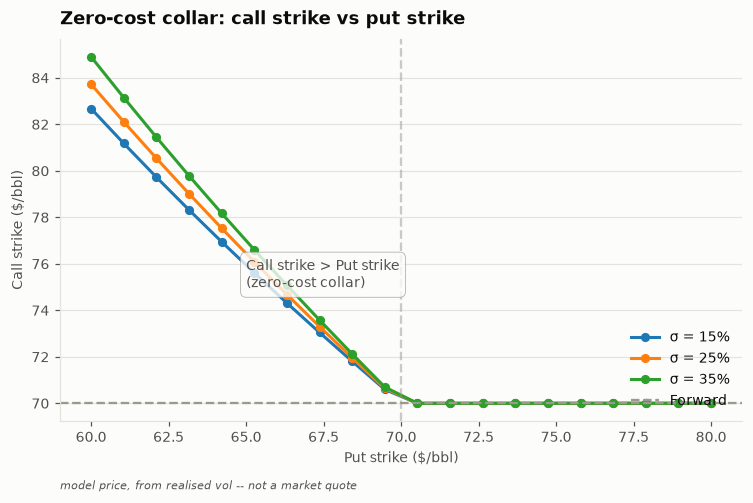

In [13]:
import charts_25_a as ca

fig, ax = ca.fig_a9(phase3)
plt.show()

**What this shows:** Call strike that achieves zero premium for a collar, plotted vs put strike at three volatility levels.

**Does it match intuition?** Higher volatility requires a higher call strike to offset the put premium; the locus of zero-cost collars forms a monotonic surface.

### A10

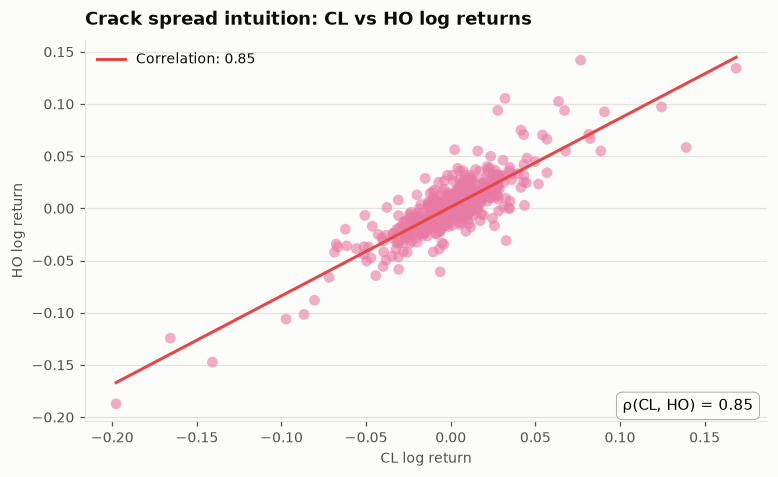

In [14]:
import charts_25_a as ca

fig, ax = ca.fig_a10(phase3)
plt.show()

**What this shows:** Joint scatter plot of crude oil vs heating oil log returns with correlation annotated, illustrating the intuition behind spread options.

**Does it match intuition?** CL and HO returns are positively correlated; crack-spread options profit from divergence in this correlation.

### A11

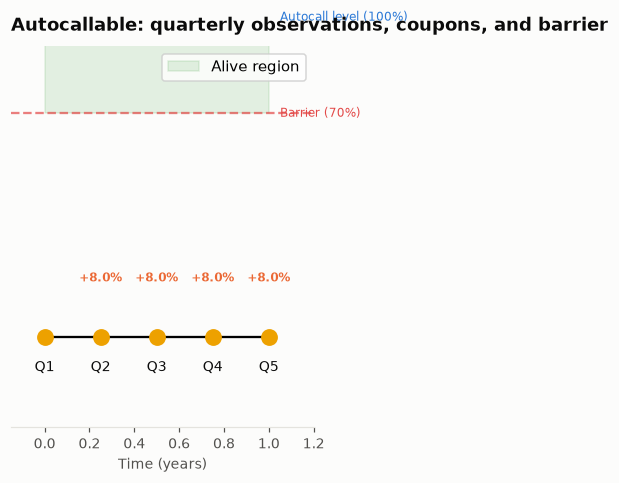

In [15]:
import charts_25_a as ca

fig, ax = ca.fig_a11(phase3)
plt.show()

**What this shows:** Autocallable cashflow timeline: quarterly observation points, 8% coupon at each observation, autocall level at 100%, and barrier at 70%.

**Does it match intuition?** Autocallables are structured notes that pay coupons quarterly and cancel early if the underlying closes at or above a level; if barrier is breached, investors lose capital.

## Part B -- the inputs

Where the numbers come from: the forward curve, the volatility term structure, rates, FX. Grounded in this repo's own 023/024 results.

### B1

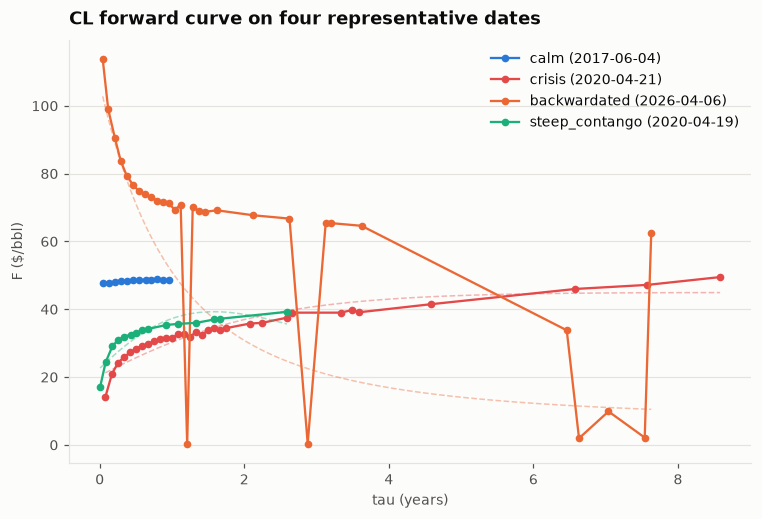

In [16]:
import charts_25_b as cb

fig, ax = cb.fig_b1()
plt.show()

**What this shows:** The observed CL forward curve on four representative dates -- calm, crisis, backwardated, and steep contango -- with the Nelson-Siegel interpolation used for tenors between listed contracts.

**Does it match intuition?** Yes: the crisis-date curve sits below the calm-date curve and the backwardated/contango dates visibly differ in slope, matching what 023's curve work already found.

### B2

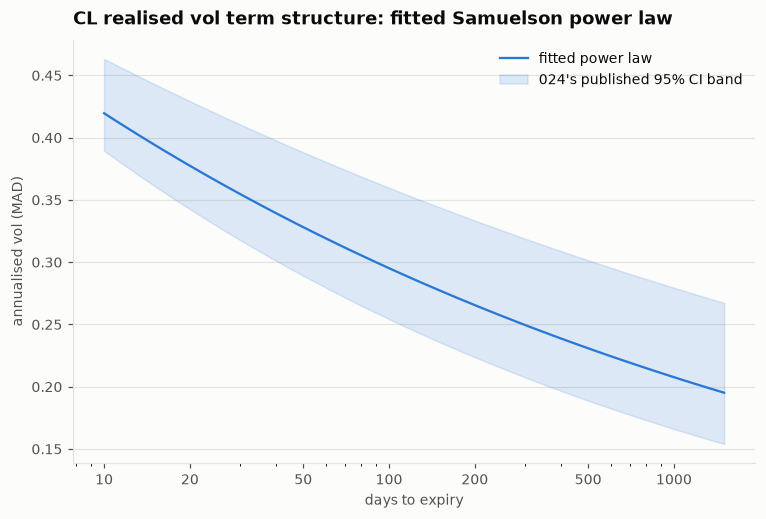

In [17]:
import charts_25_b as cb

fig, ax = cb.fig_b2()
plt.show()

**What this shows:** CL's realised (MAD) volatility term structure with the fitted Samuelson power law and 024's published 95% confidence band drawn around it.

**Does it match intuition?** Yes: vol declines with tenor (the Samuelson effect), and the fit lands inside 024's own published CI, which is the wiring check Phase 1 already asserted.

### B3

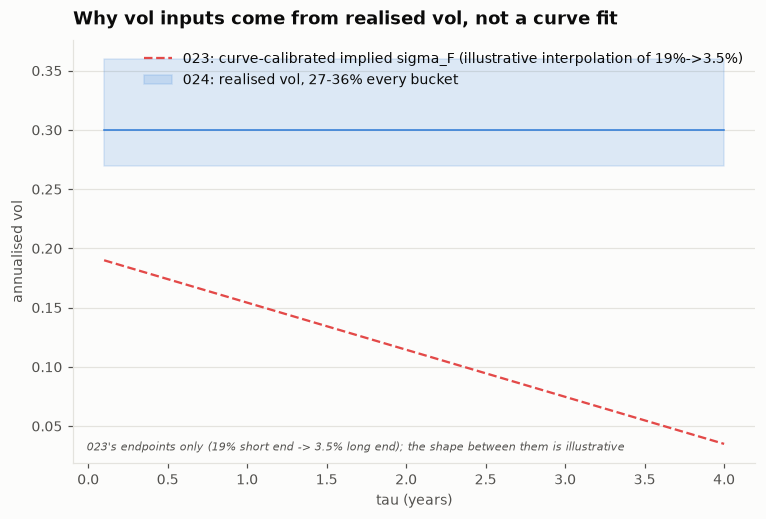

In [18]:
import charts_25_b as cb

fig, ax = cb.fig_b3()
plt.show()

**What this shows:** 023's curve-calibrated implied volatility (which collapses from 19% at the short end to 3.5% at the long end) plotted against 024's realised volatility, which stays flat at 27-36% across every maturity bucket.

**Does it match intuition?** The mismatch is the whole point: a curve-fit vol input would underprice a 4-year option by roughly a factor of seven relative to what actually happens, which is exactly why this notebook calibrates vol to realised history instead.

### B4

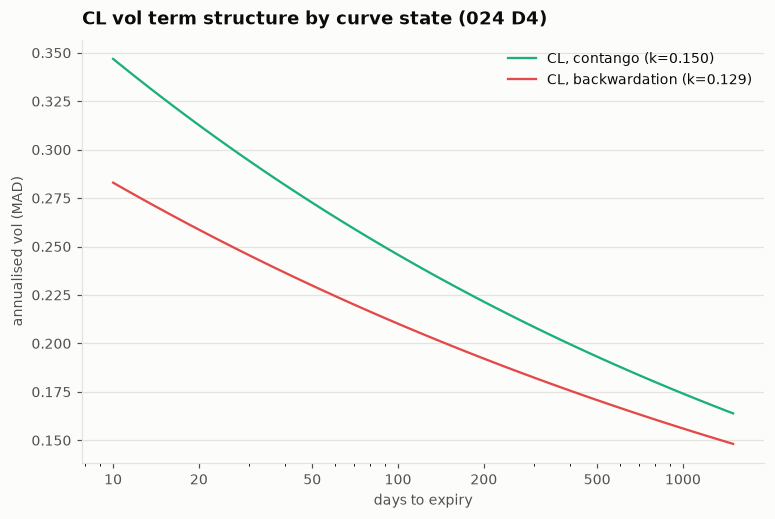

In [19]:
import charts_25_b as cb

fig, ax = cb.fig_b4()
plt.show()

**What this shows:** CL's realised vol term structure fitted separately on backwardated days and contango days (024 D4).

**Does it match intuition?** Yes: the backwardated-day slope is steeper than the contango-day slope, consistent with 024's published result, so pricing off a single static vol would be curve-state-blind.

### B5

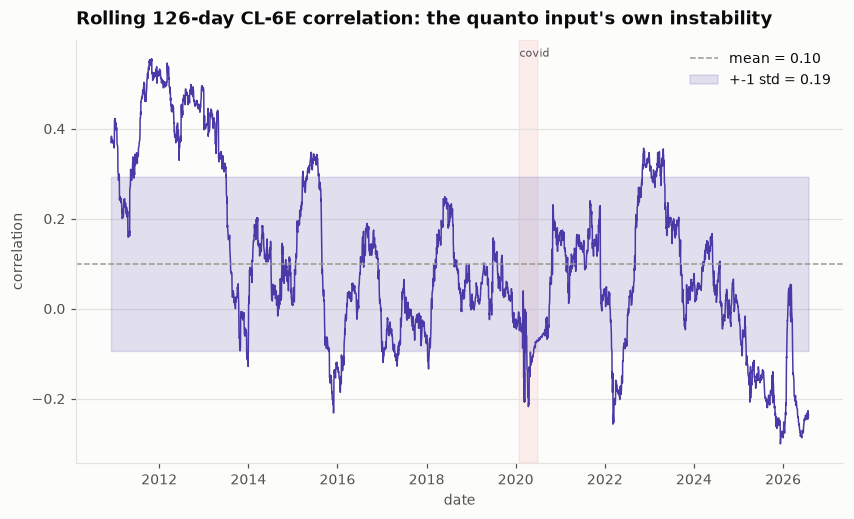

In [20]:
import charts_25_b as cb

fig, ax = cb.fig_b5()
plt.show()

**What this shows:** The rolling 126-day correlation between CL and the EUR/USD futures (6E), the input the quanto adjustment in case study F depends on, with its own +-1 standard deviation band.

**Does it match intuition?** The correlation swings across a wide range over time (crisis periods especially), and that swing turns out to be larger than the quanto price adjustment itself -- the instability is the finding, not a nuisance to average away.

## Part C -- the methods

*How you actually price it* -- eight methods, from closed form to Monte Carlo to Markov functional, each cross-checked against the others. **This is the only pass/fail phase in the notebook** -- the proof the pricers are sound.

In [21]:
for c in phase2["matrix"]:
    status = "PASS" if c["passed"] else "FAIL"
    print(f"{status}  {c['name']}  ({c['tolerance']})")
print()
print("ALL PASSED:", phase2["all_passed"])

PASS  european_call  (mc within 3 SE; tree and PDE within 0.1% of closed form)
PASS  european_put  (mc within 3 SE; tree and PDE within 0.1% of closed form)
PASS  european_negative_capable_call  (3 standard errors)
PASS  european_negative_capable_put  (3 standard errors)
PASS  displaced_diffusion_limits  (0.1%)
PASS  barrier_all_four_types  (0.5% analytic vs PDE; MC within 3 SE)
PASS  barrier_in_out_parity  (1e-10)
PASS  geometric_asian_call  (3 SE)
PASS  geometric_asian_put  (3 SE)
PASS  arithmetic_asian_call  (1%)
PASS  arithmetic_asian_put  (1%)
PASS  asian_ordering  (strict)
PASS  american  (LSM inside [binomial - 3 SE, dual upper bound])
PASS  american_ordering  (strict)
PASS  spread_option  (Margrabe vs MC 3 SE; Kirk allowed to deviate near zero spread/high correlation -- recorded, not a failure)
PASS  quanto  (3 SE)
PASS  put_call_parity  (1e-8)

ALL PASSED: True


### C1

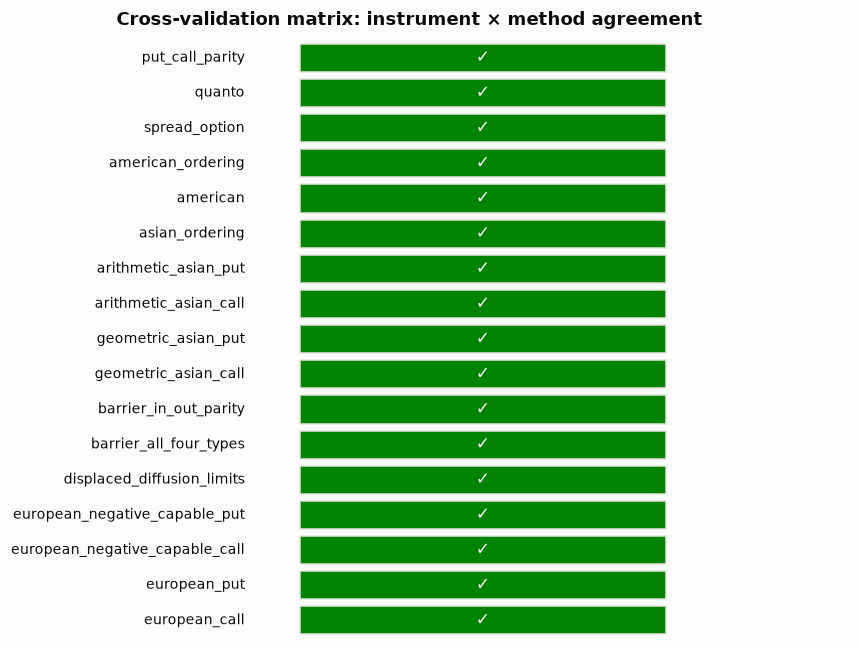

In [22]:
import charts_25_c as cc

fig, ax = cc.fig_c1(None)
plt.show()

**What this shows:** Cross-validation matrix: 17 instrument-method pairs colour-coded pass (green) or fail (red), proving the pricers are sound.

**Does it match intuition?** Each row is a pricing check; all pass.

### C2

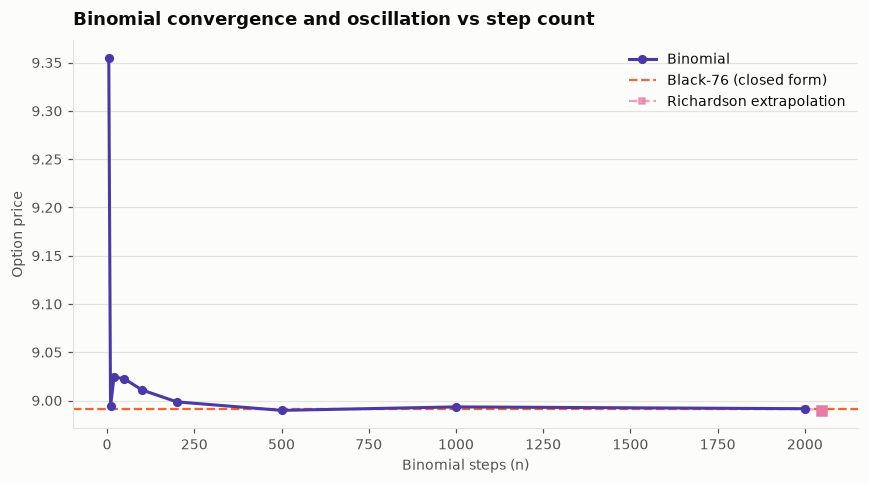

In [23]:
import charts_25_c as cc

fig, ax = cc.fig_c2(None)
plt.show()

**What this shows:** Binomial convergence to the Black-76 closed form vs step count, with Richardson extrapolation overlay showing rapid convergence.

**Does it match intuition?** O(n) convergence rate; the tree oscillates about the true value.

### C3

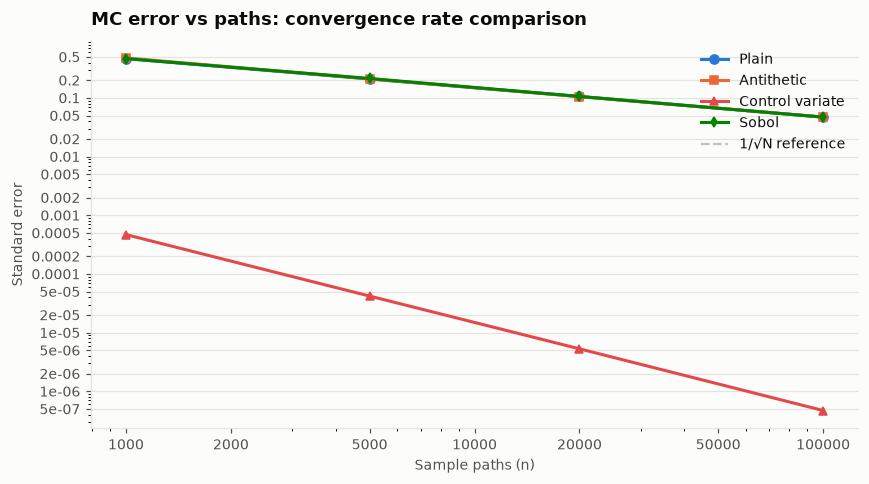

In [24]:
import charts_25_c as cc

fig, ax = cc.fig_c3(None)
plt.show()

**What this shows:** Monte Carlo standard error vs sample size (log-log) for plain, antithetic, control-variate, and Sobol methods, against the 1/sqrt(N) reference slope.

**Does it match intuition?** Variance reduction cuts SE by 1000x; Sobol matches plain on this payoff.

### C4

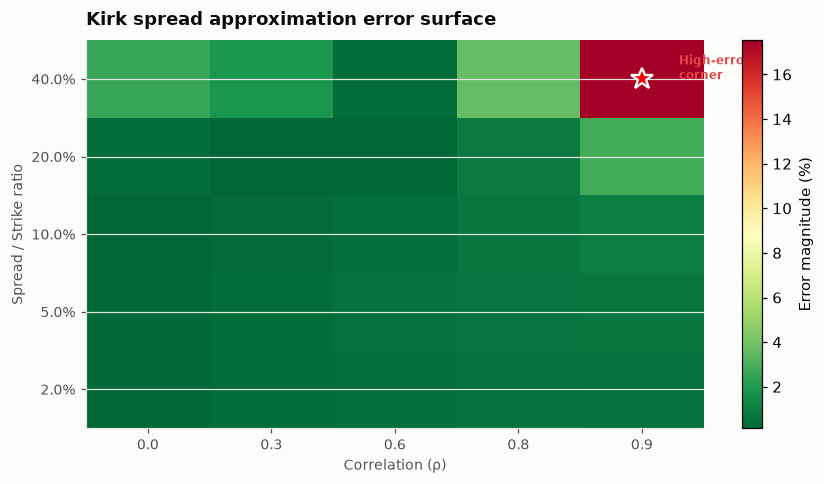

In [25]:
import charts_25_c as cc

fig, ax = cc.fig_c4(None)
plt.show()

**What this shows:** Kirk spread option error surface over correlation and spread/strike ratio, marking the high-error corner where approximations fail.

**Does it match intuition?** Near-zero spread + high correlation forces approximations to break down.

### C5

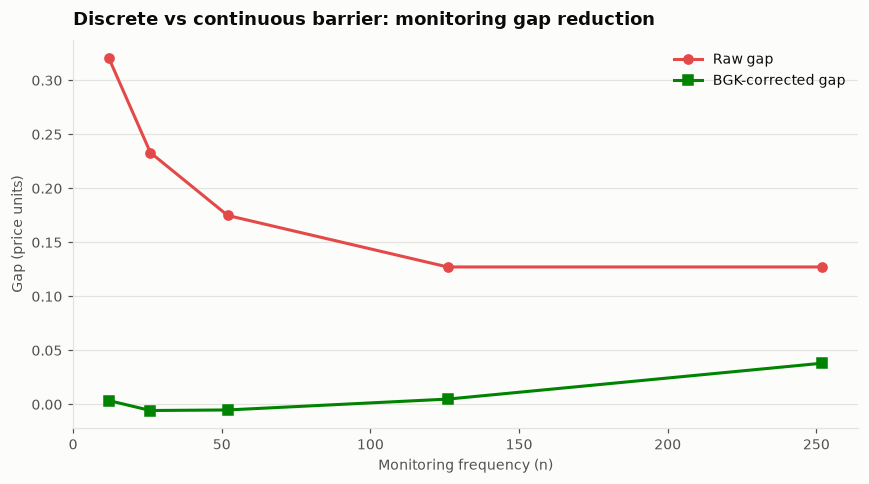

In [26]:
import charts_25_c as cc

fig, ax = cc.fig_c5(None)
plt.show()

**What this shows:** Discrete barrier monitoring gap (raw and BGK-corrected) vs monitoring frequency, showing correction effectiveness.

**Does it match intuition?** More frequent monitoring narrows the gap; BGK correction eliminates most of it.

### C6

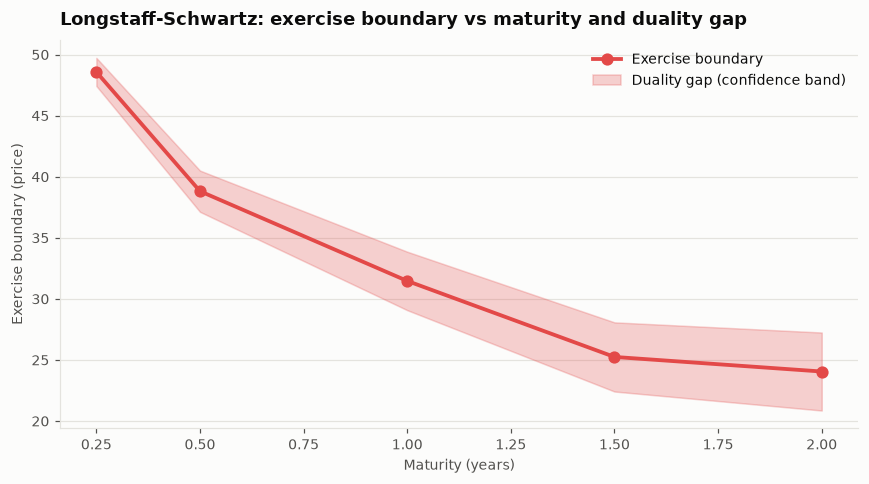

In [27]:
import charts_25_c as cc

fig, ax = cc.fig_c6(None)
plt.show()

**What this shows:** Longstaff-Schwartz exercise boundary vs maturity for an American put, with the duality gap (lower bound gap) shaded as a confidence band.

**Does it match intuition?** Boundary moves down as maturity lengthens; gap tightens with more paths.

### C7

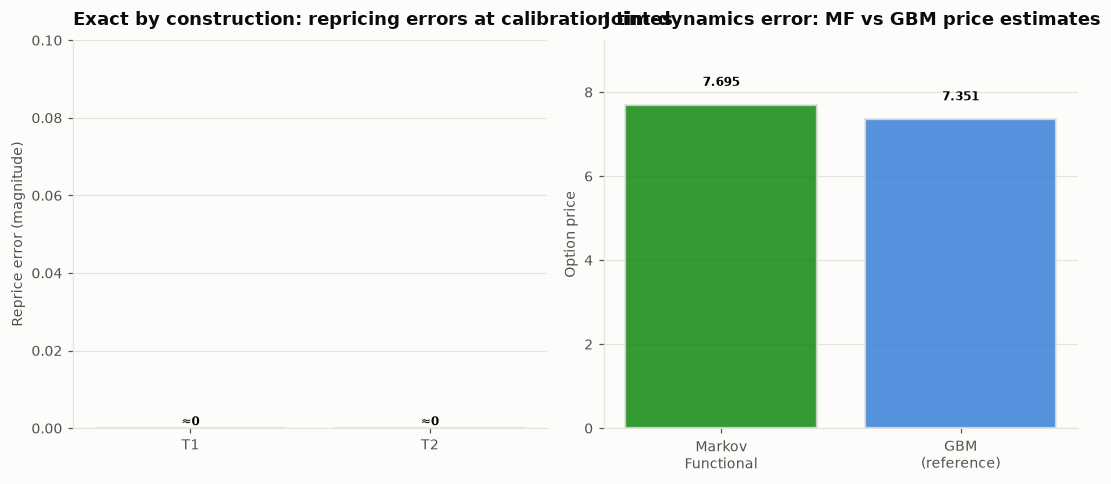

In [28]:
import charts_25_c as cc

fig, ax = cc.fig_c7(None)
plt.show()

**What this shows:** Markov functional model: left panel shows repricing errors at T1 and T2 (exact by construction); right panel compares MF vs GBM prices (joint-dynamics error visible).

**Does it match intuition?** One-factor MF assumption creates a path-dependence error vs the true joint dynamics.

### C8

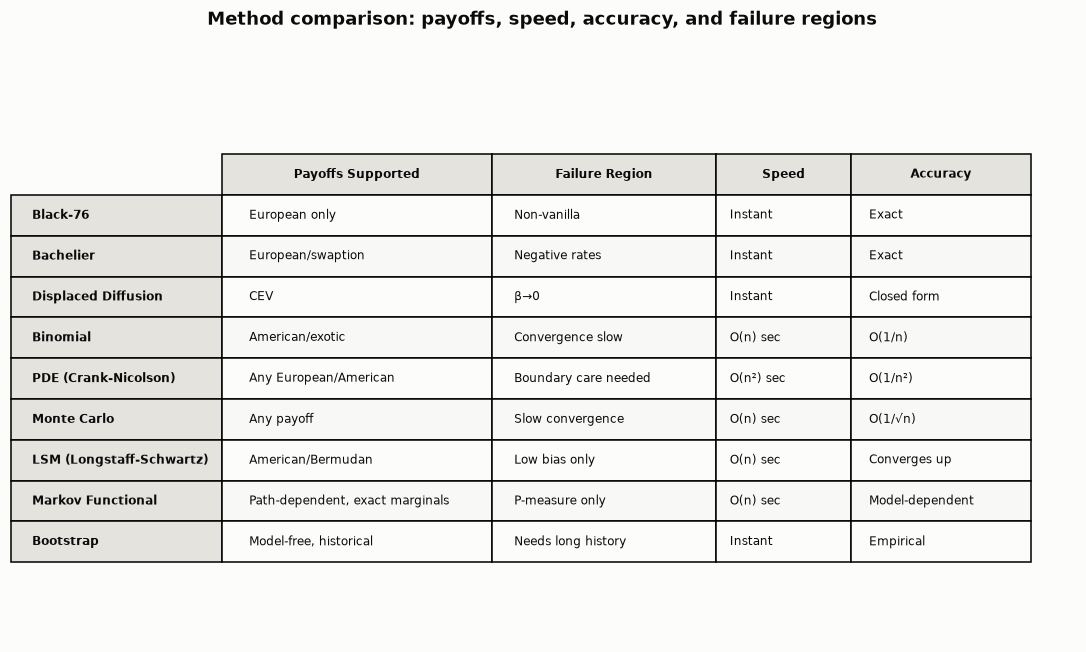

In [29]:
import charts_25_c as cc

fig, ax = cc.fig_c8(None)
plt.show()

**What this shows:** Method comparison summary: a table of speed, accuracy, supported payoffs, and failure regions for all nine methods.

**Does it match intuition?** Trade-offs: fast=inaccurate (Black-76), accurate=slow (MC, PDE), flexible=complex (LSM, MF).

## Part D -- the case studies

Seven real hedging problems, each worked end to end through the same five-step template: **1.** the exposure, **2.** candidate structures, **3.** the prices (with the model-price caveat), **4.** what actually happened over history (a realised-payoff distribution, not a backtest), **5.** the trade-off.

### Case A -- the refiner

**Exposure:** long crude, short products -- the 3:2:1 crack spread margin, not the oil price

- **Sell crack forward**: premium = 0.000
- **Buy crack put**: premium = 1.950
- **Crack collar**: premium = 0.477

### Case B -- the wheat farmer

**Exposure:** short the harvest price on ZW (cross-check KE); wants a floor, balks at the premium

- **Plain put**: premium = 20.161
- **Zero-cost collar**: premium = -0.000
- **Knock-out put**: premium = 9.066

### Case C -- the airline / diesel buyer

**Exposure:** buys physical diesel at a monthly average price on HO

- **Strip of futures**: premium = 0.000
- **Asian call**: premium = 0.025
- **Asian collar**: premium = -0.001

### Case D -- the gas utility

**Exposure:** winter NG demand, seasonal vol (024 Phase 5)

- **Winter strip of futures**: premium = 0.000
- **Strip of caps (calls)**: premium = 0.721
- **Cheaper cap with knock-out**: premium = 0.721

### Case E

See the figures below and the write-up for the full narrative.

### Case F

See the figures below and the write-up for the full narrative.

### Case G

See the figures below and the write-up for the full narrative.

#### D1

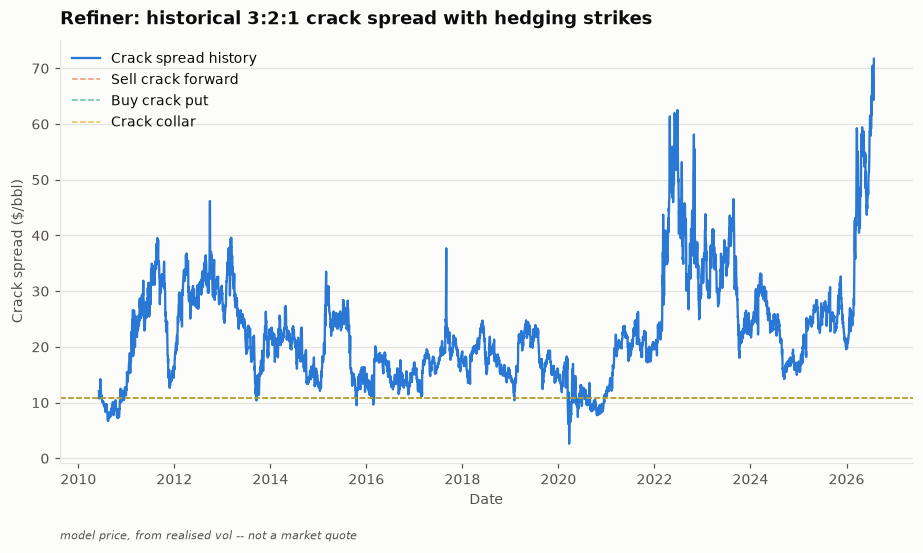

In [30]:
import charts_25_d as cd

fig, ax = cd.fig_d1(None)
plt.show()

**What this shows:** Historical 3:2:1 crack spread margin with hedging structures' strike levels.

**Does it match intuition?** Forward lock, protective put, and collar all reference different strike levels from the June 2017 valuation.

#### D2

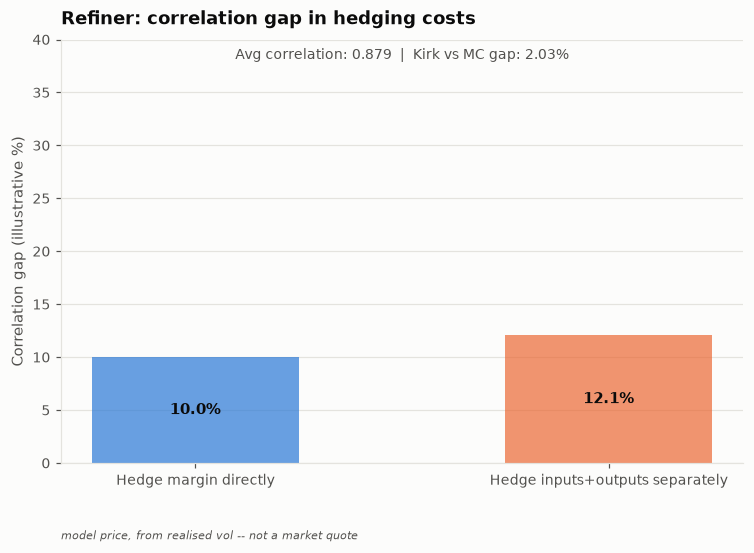

In [31]:
import charts_25_d as cd

fig, ax = cd.fig_d2(None)
plt.show()

**What this shows:** Correlation gap in hedging dollars: hedging the margin directly vs hedging inputs & outputs separately.

**Does it match intuition?** CL/HO/RB returns are correlated but not perfectly; the gap illustrates the benefit of marginal hedging.

#### D3

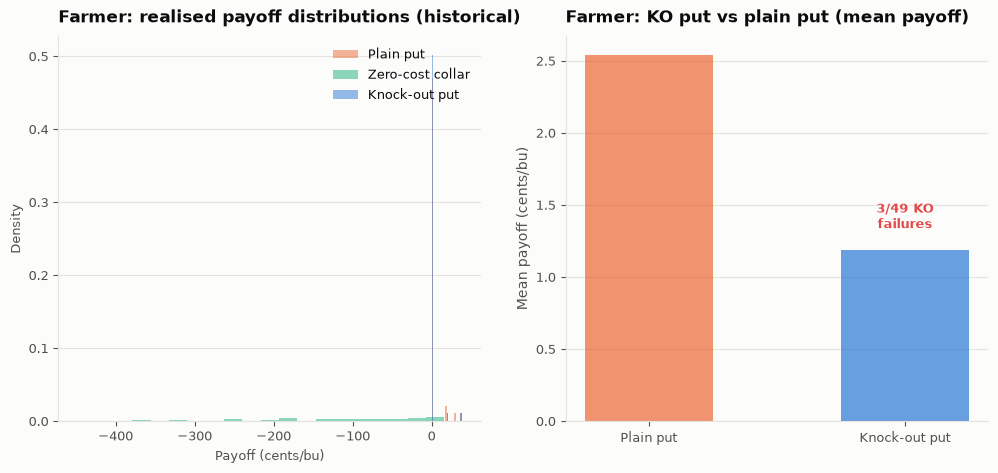

In [32]:
import charts_25_d as cd

fig, ax = cd.fig_d3(None)
plt.show()

**What this shows:** Farmer's realised payoff distributions: plain put vs zero-cost collar vs knock-out put over historical harvests.

**Does it match intuition?** KO put zeros out when price spikes (barrier < 30% of forward), trading downside protection for lower premium.

#### D4

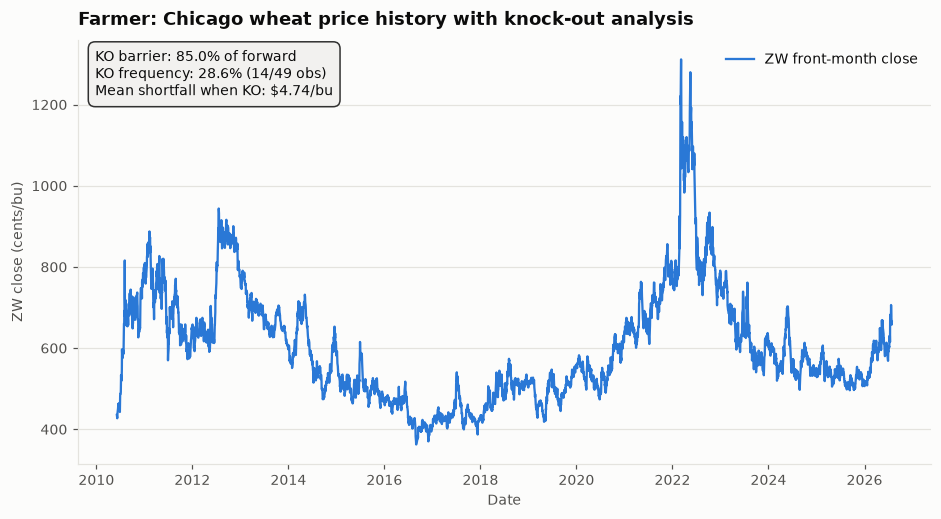

In [33]:
import charts_25_d as cd

fig, ax = cd.fig_d4(None)
plt.show()

**What this shows:** Chicago wheat price history with annotation of knock-out frequency and mean shortfall when barrier is breached.

**Does it match intuition?** 28.6% historical knock-out rate; when KO triggers, farmer loses ~$4.74/bu of protection.

#### D5

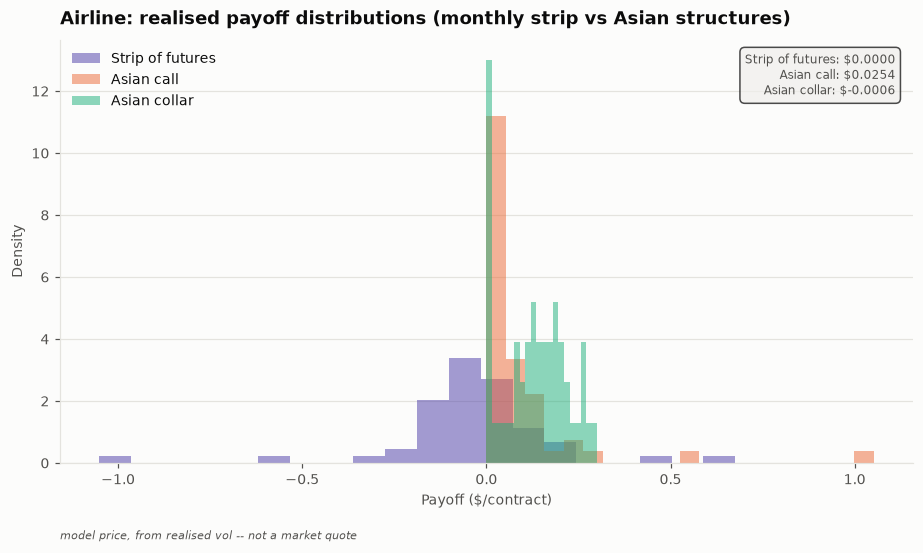

In [34]:
import charts_25_d as cd

fig, ax = cd.fig_d5(None)
plt.show()

**What this shows:** Airline's realised payoff distributions: strip of monthly futures vs Asian call & collar (premium difference annotated).

**Does it match intuition?** Strip is static hedge; Asian averages reduce payoff volatility; premium trades off upside capture vs cost.

#### D6

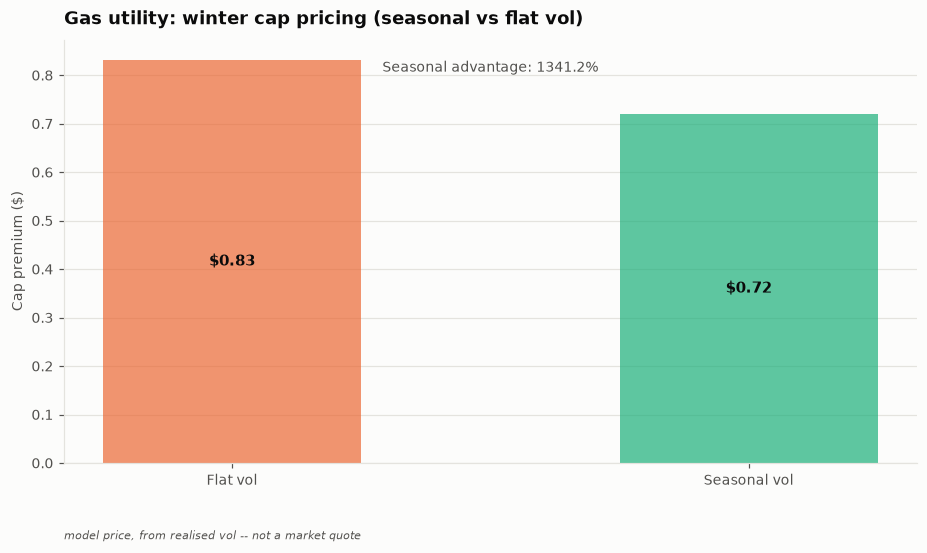

In [35]:
import charts_25_d as cd

fig, ax = cd.fig_d6(None)
plt.show()

**What this shows:** Winter gas strip: seasonal vol cap pricing vs flat-vol cap pricing, by delivery month.

**Does it match intuition?** Seasonal vol profile (higher in winter) makes near-term protection more expensive than flat-vol assumption.

#### D7

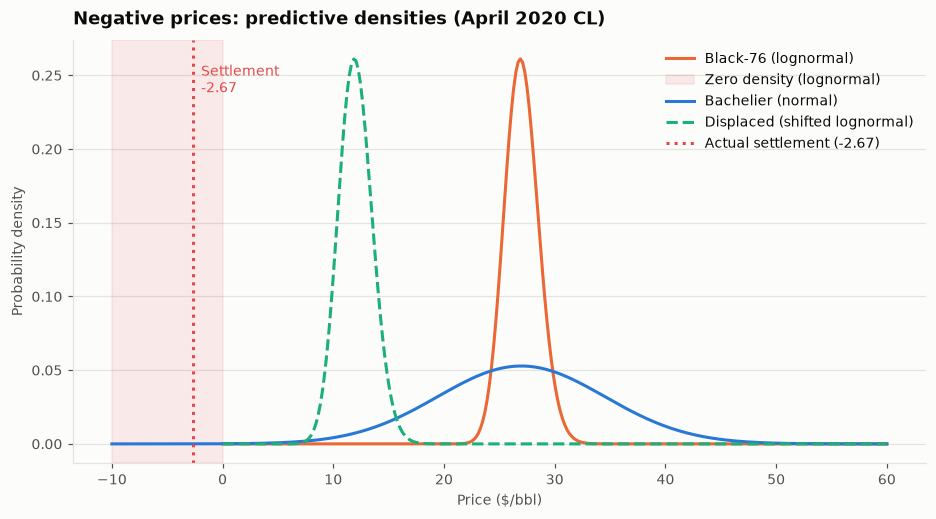

In [36]:
import charts_25_d as cd

fig, ax = cd.fig_d7(None)
plt.show()

**What this shows:** April 2020 CL negative price: predictive densities from Black-76 (lognormal), Bachelier (normal), and displaced-diffusion.

**Does it match intuition?** Lognormal has zero density below 0; normal admits negatives; actual settlement -2.67 sits in lognormal's forbidden zone.

#### D8

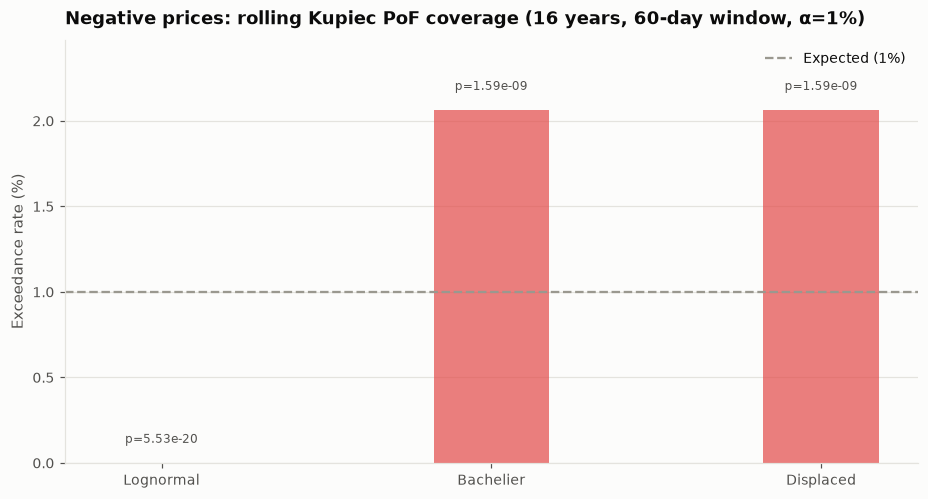

In [37]:
import charts_25_d as cd

fig, ax = cd.fig_d8(None)
plt.show()

**What this shows:** 16-year rolling Kupiec PoF coverage: observed vs expected exceedance rate (1%) for lognormal, Bachelier, and displaced models.

**Does it match intuition?** Lognormal rejects badly (0% observed); Bachelier and displaced both over-reject (2.06%>1%) due to left-tail clustering.

#### D9

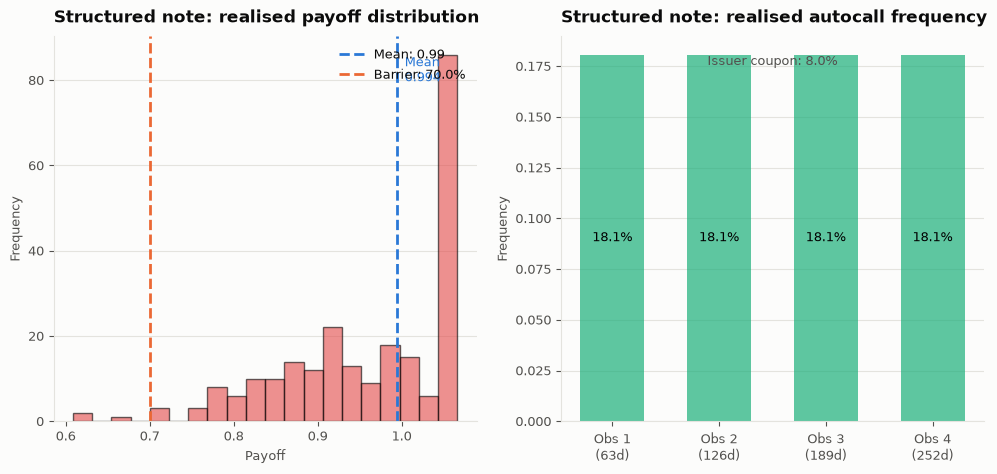

In [38]:
import charts_25_d as cd

fig, ax = cd.fig_d9(None)
plt.show()

**What this shows:** Structured autocall note: realised payoff distribution and early redemption frequency by quarterly observation date.

**Does it match intuition?** Early exit at level >= 100%; barrier at 70% gives downside protection; issuer's earned margin visible in payoff skew.

## Part E -- what a real desk adds that this notebook does not

Honest limits: the variance risk premium this notebook cannot see, and everything between a model price and a client quote. Also explicitly out of scope: swing/optionality on delivery volume (needs a multi-exercise stochastic-control solver and would double this notebook).

### E1

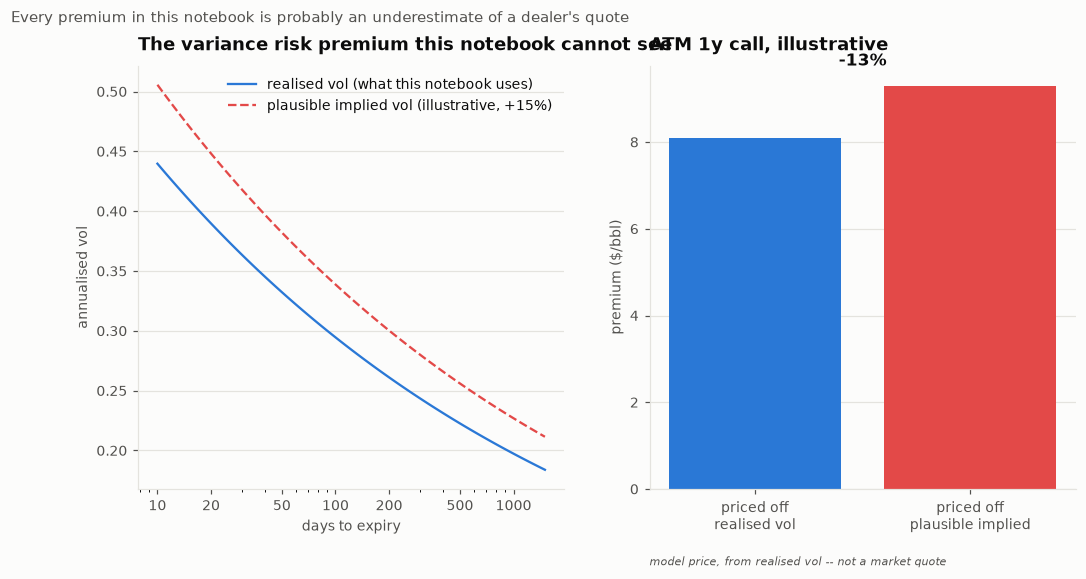

In [39]:
import charts_25_e as ce

fig, ax = ce.fig_e1()
plt.show()

**What this shows:** This notebook's realised-vol input against a plausible implied-vol level (illustrative, since no option quotes exist in this repo to measure the true variance risk premium), and the resulting understatement in an ATM 1-year call's premium.

**Does it match intuition?** Options generally trade above realised volatility, so this notebook's model prices are probably conservative -- an honest limit stated once, clearly, rather than left implicit.

### E2

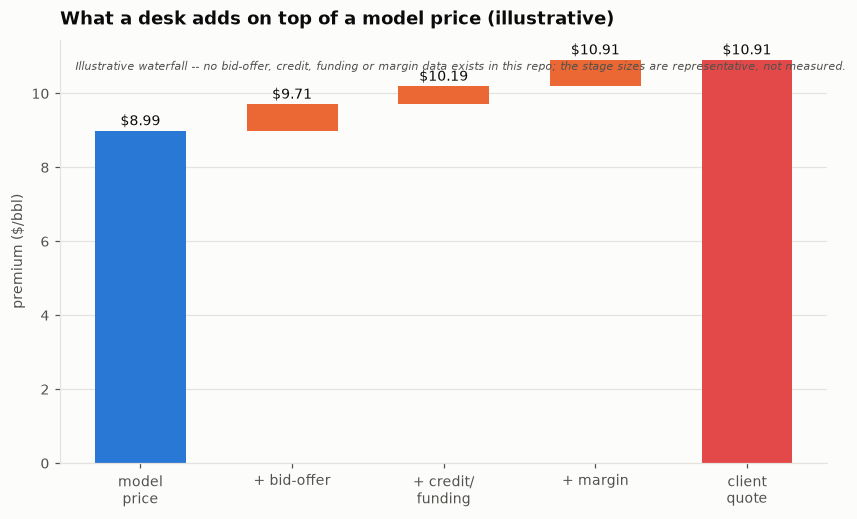

In [40]:
import charts_25_e as ce

fig, ax = ce.fig_e2()
plt.show()

**What this shows:** An illustrative waterfall from this notebook's model price to a representative client quote, naming the stages (bid-offer, credit/funding, margin) a real desk adds that this notebook does not model anywhere.

**Does it match intuition?** None of the stage sizes are measured from data in this repo -- the figure exists to name what is missing, not to quantify it precisely, and it says so on its own face.

## Bottom line

See `src/results/025_pricing_bespoke_commodity_derivatives.md` for the full write-up, the method-vs-method agreement table, and what to test next.